In [1]:
import os
import torch
import numpy as np
from extract import extract_graph, extract_die_area, load_file_content
import scipy.sparse as sp 
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking , load_cts_parameters
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_dir = "dataset_with_def/placement_files/"
csv_dir = "dataset_with_def/"



In [2]:
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

class SpatialClusterHead(nn.Module):
    def __init__(self, feature_dim, num_clusters):
        super().__init__()
        self.spatial_mlp = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, num_clusters)
        )
        self.feature_mlp = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_clusters)
        )
        
        # THE FIX: Equalizers
        # This prevents the feature_mlp from bullying the spatial_mlp
        self.spatial_norm = nn.LayerNorm(num_clusters)
        self.feature_norm = nn.LayerNorm(num_clusters)
        
    def forward(self, X_combined, spatial_weight=3.0):
        spatial_logits = self.spatial_mlp(X_combined[:, :2])
        feature_logits = self.feature_mlp(X_combined)
        
        # Normalize both to unit variance before combining
        s = spatial_logits / (spatial_logits.std() + 1e-8)
        f = feature_logits / (feature_logits.std() + 1e-8)
        
        
        return spatial_weight * s + f

class FirstTerm(nn.Module):
    def __init__(self, num_cell_types, num_of_clusters , embedding_dim=8):
        super().__init__()
        self.cell_embedding = nn.Embedding(num_cell_types, embedding_dim)
        # Initialize 10.9M weights (The Dials)
        feature_dim = 18 + embedding_dim
        self.edge_mlp = nn.Sequential(
            nn.Linear(feature_dim*2, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

        nn.init.normal_(self.edge_mlp[2].weight, mean=0.0, std=0.001)
        nn.init.constant_(self.edge_mlp[2].bias, 0.01)


        # 3. THE DUAL-PATH CLUSTER HEAD
        # Replaces the standard Sequential MLP
        self.cluster_head = SpatialClusterHead(
            feature_dim=feature_dim, 
            num_clusters=num_of_clusters
        )



    def forward(self, X, X_cell_ids, num_nodes, p_indices, A_skip_csr, current_k, tau=1.0):
        
        X_cell_ids = X_cell_ids.squeeze()
        cell_features = self.cell_embedding(X_cell_ids)  # Shape: [num_nodes, embedding_dim]
        X_combined = torch.cat([X, cell_features], dim=1)  # Shape: [num_nodes, 18 + embedding_dim]

        src_features = X_combined[p_indices[0]]  # Shape: [num_edges, feature_dim]
        dst_features = X_combined[p_indices[1]]  # Shape: [num_edges, feature_dim]
        edge_inputs = torch.cat([src_features, dst_features], dim=1)  # Shape: [num_edges, feature_dim*2]

        dynamic_p_weights = self.edge_mlp(edge_inputs).squeeze(-1)
        safe_weights = F.softplus(dynamic_p_weights) 


        


        # Enforce P >= 0 and build sparse matrix
        P = torch.sparse_coo_tensor(p_indices, safe_weights, 
                                    (num_nodes, num_nodes)).coalesce()
        
        # Reconstruction: XP
        X_hat = torch.sparse.mm(P, X)
        
        # Loss: ||X - XP||
        error = X - X_hat
        loss1 = torch.mean(error**2)   

        # Pass all node features through the head
        logits = self.cluster_head(X_combined) # Shape: [n, k]

        logits = logits[:, :current_k]
        
        #TERM2
        #C matrix with probability distribution across clusters for each node
        C = F.gumbel_softmax(logits, tau=tau, hard=False) # Shape: [n, k]
        # Inside FirstTerm.forward or the training loop
        # tau_smooth = 0.6  # Higher = more spread out/soft
        # C = F.softmax(logits / tau_smooth, dim=-1)
        # C = F.softmax(logits, dim=-1)  # Ensure positivity for SDDMM

        p_vals = P.values()
        
        # 1. Sum across rows (dim=1) to get the total weight leaving each node
        row_sums = torch.sparse.sum(P, dim=1).to_dense()
        
        # 2. Expand row_sums to match the non-zero values 
        # P.indices()[0] contains the row index for every specific edge
        p_vals_norm = p_vals / (row_sums[P.indices()[0]] + 1e-8)
        
        # Rebuild using the exact same sorted indices
        P_norm = torch.sparse_coo_tensor(P.indices(), p_vals_norm, 
                                         (num_nodes, num_nodes)).coalesce()
        
        # 2. Convert to CSR format (Required for the CUDA SDDMM engine)
        P_csr = P_norm.to_sparse_csr()
        
        # 3. SDDMM Magic! 
        # beta=1.0, alpha=-1.0 calculates exactly: (1.0 * P_csr) - (1.0 * C @ C^T)
        # It ONLY calculates this at the 10.9M non-zero locations!
        diff_csr = torch.sparse.sampled_addmm(P_csr, C, C.t(), beta=1.0, alpha=-1.0)
        
        # 4. Square the differences and sum them
        loss2 = torch.sum(diff_csr.values() ** 2)


        #TERM3
        M = torch.matmul(C.t(), torch.sparse.mm(A_skip_csr, C))  # [k, n] @ [n, n] @ [n, k] -> [k, k]
        # 2. Normalize M into a probability distribution (M_tilde)
        M = torch.clamp(M, min=0)
        M_tilde = M / (M.sum() + 1e-8)
        loss3 = -torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        # 3. Calculate Shannon Entropy: -sum(p * log(p))
        # We only calculate for non-zero entries to avoid log(0)
        # loss3 = torch.sum(M_tilde * torch.log(M_tilde + 1e-8))

        

        alpha_1 = 1.0 
        alpha_2 = 1.0    
        alpha_3 = 1.0    
        loss = alpha_1* loss1 + (alpha_2 * loss2) +(alpha_3 * loss3) 



        return  loss, loss1 , loss2, loss3,  C , X_combined


import math
def get_tau(epoch):
    tau_start = 2.0
    tau_mid = 1.35   # Targets ~25% Confidence for the middle flatline
    tau_end = 0.85   # Targets ~40% Confidence for the final floor

    if epoch < 75:
        # Phase 1: Smooth descent to the middle flatline
        progress = epoch / 75.0
        return tau_mid + 0.5 * (tau_start - tau_mid) * (1 + math.cos(math.pi * progress))
        
    elif epoch < 150:
        # Phase 2: THE MIDDLE FLATLINE (Epoch 75 to 150)
        return tau_mid
        
    elif epoch < 200:
        # Phase 3: Smooth descent to the final floor
        progress = (epoch - 150) / 50.0
        return tau_end + 0.5 * (tau_mid - tau_end) * (1 + math.cos(math.pi * progress))
        
    else:
        # Phase 4: THE FINAL FLATLINE (Epoch 200 to 250+)
        return tau_end

In [3]:
import math

def get_true_compactness_loss(C, positions):
    """
    Dynamically balances tight spatial grouping with 100% cluster utilization.
    Guaranteed to stay positive. Perfect utilization = 0.0 penalty.
    """
    # ==========================================
    # FORCE 1: THE VACUUM (Smooth Spatial Penalty)
    # ==========================================
    weights = C.sum(dim=0) + 1e-8  
    centroids = (C.T @ positions) / weights.unsqueeze(1)  
    
    pos_sq = torch.sum(positions**2, dim=1, keepdim=True)
    cent_sq = torch.sum(centroids**2, dim=1)
    dists_sq = pos_sq + cent_sq - 2 * (positions @ centroids.T)
    
    spatial_loss = (C * (dists_sq ** 2)).sum(dim=1).mean()
    
    # ==========================================
    # FORCE 2: THE WATER PRESSURE (Utilization Reward)
    # ==========================================
    avg_probs = C.mean(dim=0)  # [K]
    K = C.size(1)
    
    # The maximum possible entropy is exactly log(K)
    max_entropy = math.log(K)
    
    # This value is naturally negative
    neg_entropy = torch.sum(avg_probs * torch.log(avg_probs + 1e-10))
    
    # By adding them, perfect balance = 0.0. Complete collapse = +max_entropy.
    utilization_loss = max_entropy + neg_entropy
    
    # ==========================================
    # DYNAMIC BALANCE
    # ==========================================
    # Because utilization_loss is now a smaller positive number (0 to ~6.8),
    # you might need to slightly bump gamma if it doesn't utilize all clusters.
    gamma = 5.0 
    
    return spatial_loss + (gamma * utilization_loss)

In [4]:
from helper import relative_masking
import random , os
from helper import normalize_features, build_X_hop_mask , get_compressed_graph , relative_masking , load_cts_parameters

# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# according to number of your cts knobs
NUM_CTS_KNOBS = 4 
metadata = torch.load("global_metadata.pt")
global_max_cell_types = metadata['global_max_cell_types']
global_max_k = metadata['global_max_k']

model = FirstTerm(num_cell_types=global_max_cell_types, num_of_clusters=global_max_k).to(device)
# gnn_model = HeteroCTS_GNN(input_dim=28, hidden_dim=64, num_params=NUM_CTS_KNOBS).to(device)

# FIXED: Optimizer now tracks BOTH models for Joint Optimization 
# optimizer = optim.Adam(list(model.parameters()) + list(gnn_model.parameters()), lr=0.01)

# ONLY track Phase 1 for this script
optimizer = optim.Adam(model.parameters(), lr=0.01)

processed_dir = "processed_graphs"
# List all processed file names
design_files = [f for f in os.listdir(processed_dir) if f.endswith('.pt')]

grouped_designs = {}
for f in design_files:
    # Splits "aes_run_20260306..." to extract just "aes"
    base_name = f.split('_run_')[0] 
    if base_name not in grouped_designs:
        grouped_designs[base_name] = []
    grouped_designs[base_name].append(f)

# 2. Pick exactly 20 from each category
balanced_files = []
for name, files in grouped_designs.items():
    random.shuffle(files)          # Shuffle within the category
    selected = files[:20]           # Take exactly 20 (or less if a category has < 20)
    balanced_files.extend(selected)

# 3. Final shuffle so the epoch isn't ordered by chip type
random.shuffle(balanced_files)
design_files = balanced_files      # Overwrite the main list

print(f"🔥 Fast-Tracking on {len(design_files)} perfectly balanced designs!")
# Quick check to prove it's balanced
print("Balance Check:", {name: len([x for x in design_files if name in x]) for name in grouped_designs.keys()})

# ==========================================
# RAM CACHING: Pre-load the 20 chips into System Memory
# ==========================================
print("\n📦 Pre-loading mini-dataset into System RAM to maximize speed...")
ram_cache = []

for filename in design_files:
   
    # map_location='cpu' guarantees it stays in your 16GB/32GB System RAM, protecting the 8GB GPU
    data = torch.load(os.path.join(processed_dir, filename), map_location='cpu')
    ram_cache.append((filename, data))
    
print("✅ Pre-loading complete! Starting training loop...\n")
 

for epoch in range(301):
    
    current_tau = get_tau(epoch)

    # --- Reshuffle every epoch to prevent sequence memorization ---
    random.shuffle(ram_cache)
    
    # Added confidence tracker
    total_l, l1_sum, l2_sum, l3_sum, conf_sum = 0, 0, 0, 0, 0
    total_task_loss, total_skew_l, total_power_l, total_wl_l = 0, 0, 0, 0 
    l_spatial = 0
    L_compact_sum = 0
    
    for i, (filename,data) in enumerate(ram_cache):
        

        
        optimizer.zero_grad()

        # 3. TRANSFER: Move ONLY what you need to the GPU
        X = data['X'].to(device)
        X_cell_ids = data['X_cell_ids'].to(device , non_blocking=True)
        p_indices = data['p_indices'].to(device, non_blocking=True)
        A_skip_csr = data['A_skip_csr'].to(device, non_blocking=True)
        A_wire_csr = data['A_wire_csr'].to(device, non_blocking=True)

        # =========================================================
        # SPATIAL BOOST: Force the model to "feel" X/Y more
        # =========================================================
        X_weighted = X.clone()
        spatial_weight = 10.0  # Start with 10.0 to kill those ring clusters
        X_weighted[:, :2] *= spatial_weight 
        # =========================================================

        lambda_phys = 500.0
        


       # 1. Forward Pass
        # We ignore the first return 'loss' because it uses the model's internal (weaker) weighting
        _, l1, l2, l3, C, X_combined = model(
            X, 
            X_cell_ids,
            data['num_nodes'], 
            p_indices, 
            A_skip_csr,
            data['current_k'],
            tau=current_tau
        )

        # 2. THE SPATIAL HAMMER 
        # Increase this to 100.0 or 500.0 if clusters are still spanning the chip
        # lambda_spatial = 1
        # l_phys, l_feat = get_feature_aware_spatial_loss(C, X[:, :2], X_combined)
        
        # We manually build the objective function to force the optimizer to prioritize L2
        lambda_phys = 100.0  
        lambda_feat = 50.0   

        L_compact = get_true_compactness_loss(C, X[:, :2])
        lambda_compact = 10000.0

        custom_total_loss = l1 + l2 +  + l3 + lambda_compact * L_compact

        # 3. BACKPROP: This is where the magic happens
        custom_total_loss.backward()
        optimizer.step()
        
        # 4. LOGGING: Make sure you log the CUSTOM loss, not the raw one
        total_l += custom_total_loss.item()
        l1_sum += l1.item()
        l2_sum += l2.item()
        l3_sum += l3.item()
        L_compact_sum += L_compact
        # l_spatial += l_spatial.item()
        # l_spatial_phys_sum += l_phys.item()
        # l_spatial_feat_sum += l_feat.item()

        
        # Calculate cluster confidence: How "sure" the model is about its clusters
        # We take the max probability for each node and average them.
        with torch.no_grad():
            conf_sum += C.max(dim=1)[0].mean().item()

        


# ----------------------------------------
    # CORRECTED LOGGING BLOCK
    # ----------------------------------------
    if epoch % 10 == 0:
        n = len(design_files)
        log_str = (f"Epoch {epoch:3} | Base Loss: {total_l/n:.4f} | "
                   f"L1: {l1_sum/n:.4f} | L2: {l2_sum/n:.4f} | L3: {l3_sum/n:.4f} | LCompact: {L_compact_sum/n:.4f}"
                   f"Conf: {(conf_sum/n)*100:.2f}%")    
                   
        print(log_str)

torch.save(model.state_dict(), "phase1_clustering_ep250_twohop.pt")
print("✅ Saved! Ready to load these into the Joint-Optimization script.")   

🔥 Fast-Tracking on 80 perfectly balanced designs!
Balance Check: {'ethmac': 20, 'aes': 20, 'picorv32': 20, 'sha256': 20}

📦 Pre-loading mini-dataset into System RAM to maximize speed...


/home/rain/CTS-Task-Aware-Clustering/venv/lib/python3.12/site-packages/torch/_utils.py:361: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  result = torch.sparse_compressed_tensor(


✅ Pre-loading complete! Starting training loop...

Epoch   0 | Base Loss: 17503.6626 | L1: 124.7014 | L2: 677.5306 | L3: 13.5647 | LCompact: 1.6688Conf: 5.23%
Epoch  10 | Base Loss: 5342.0821 | L1: 0.7491 | L2: 564.3202 | L3: 12.9816 | LCompact: 0.4764Conf: 8.69%
Epoch  20 | Base Loss: 4205.3389 | L1: 0.6553 | L2: 545.9003 | L3: 12.7561 | LCompact: 0.3646Conf: 10.44%
Epoch  30 | Base Loss: 3555.4061 | L1: 0.6901 | L2: 537.1991 | L3: 12.5933 | LCompact: 0.3005Conf: 12.31%
Epoch  40 | Base Loss: 2687.3416 | L1: 0.6123 | L2: 533.9363 | L3: 12.4300 | LCompact: 0.2140Conf: 14.65%
Epoch  50 | Base Loss: 2386.2360 | L1: 0.6198 | L2: 539.9371 | L3: 12.2825 | LCompact: 0.1833Conf: 17.07%
Epoch  60 | Base Loss: 2285.1218 | L1: 0.8079 | L2: 552.9027 | L3: 12.2113 | LCompact: 0.1719Conf: 19.12%
Epoch  70 | Base Loss: 2181.0953 | L1: 0.5932 | L2: 560.6015 | L3: 12.1600 | LCompact: 0.1608Conf: 20.50%
Epoch  80 | Base Loss: 2077.4359 | L1: 0.6210 | L2: 562.3773 | L3: 12.1315 | LCompact: 0.1502Conf: 2


📊 CLUSTER UTILIZATION REPORT
-------------------------------
Total Capacity:    71
Hard-Filled:       71 clusters
Utilization:       100.00%
Effective K:       64.40

--- TRUTH Breakdown for 5 Clusters ---

Cluster 52 (Total Nodes: 21):
  Node   166 | Prob: 1.0000 | Coord: (-1.091, -0.540)
  Node   192 | Prob: 1.0000 | Coord: (-0.752, -0.390)
  Node   188 | Prob: 1.0000 | Coord: (-0.807, -0.465)
  Node   613 | Prob: 1.0000 | Coord: (-0.862, -0.315)
  Node   641 | Prob: 1.0000 | Coord: (-1.191, -0.239)
  Node   126 | Prob: 1.0000 | Coord: (-1.456, -0.390)
  Node   602 | Prob: 1.0000 | Coord: (-0.834, -0.089)
  Node   181 | Prob: 1.0000 | Coord: (-1.072, -0.239)
  Node   645 | Prob: 1.0000 | Coord: (-1.091, -0.315)
  Node   950 | Prob: 1.0000 | Coord: (-1.639, -0.766)

Cluster 5 (Total Nodes: 16):
  Node  1163 | Prob: 1.0000 | Coord: (-2.197, -0.315)
  Node   199 | Prob: 1.0000 | Coord: (-1.136, -0.616)
  Node   125 | Prob: 1.0000 | Coord: (-1.411, -0.239)
  Node   197 | Prob: 1.0000 | 

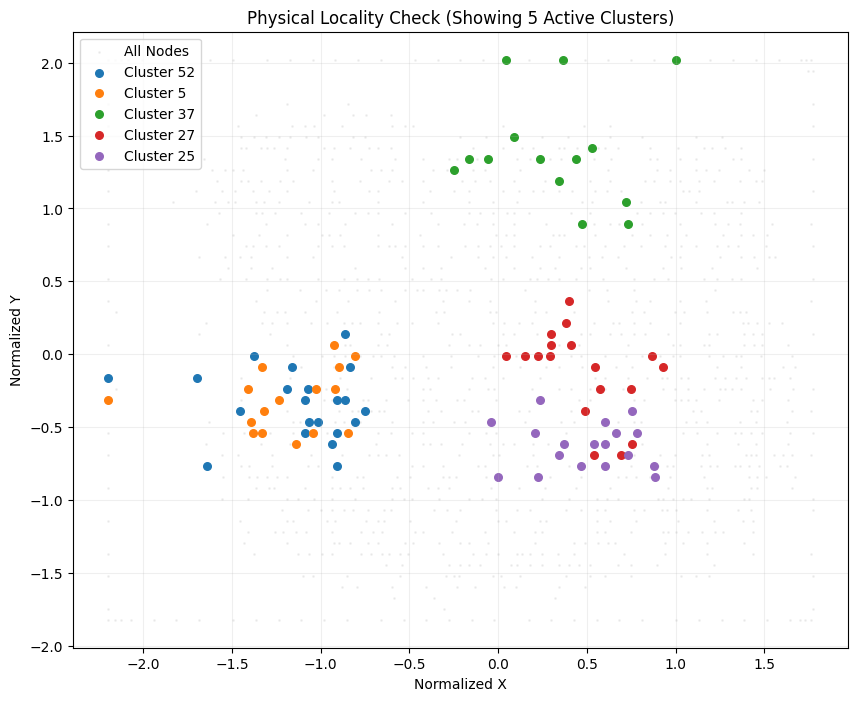

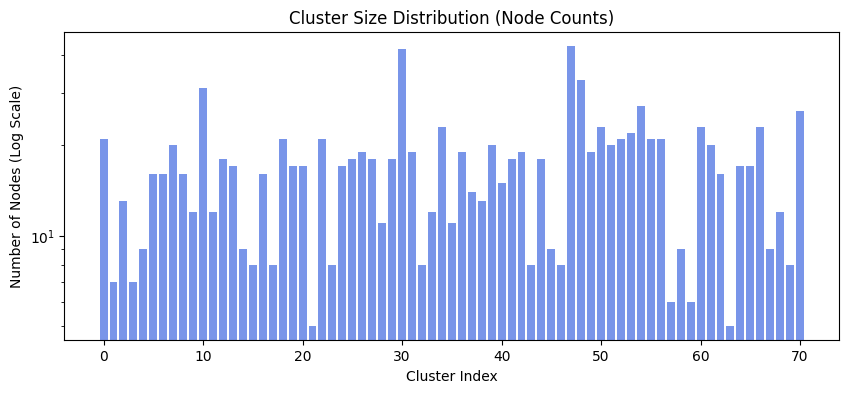

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_clusters(model_path, data_path, num_clusters_to_show=5, top_n=10):
    # 1. Load Model and Data
    metadata = torch.load("global_metadata.pt")
    model = FirstTerm(num_cell_types=metadata['global_max_cell_types'], 
                      num_of_clusters=metadata['global_max_k']).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    data = torch.load(data_path)
    X = data['X'].to(device)
    X_cell_ids = data['X_cell_ids'].to(device)
    
    # 2. Get the C matrix (Assignments)
    with torch.no_grad():
        # Feed the raw X (no boosting!) so it matches what it learned in training
        loss, l1, l2, l3, C, X_comb = model(
            X, X_cell_ids, data['num_nodes'], data['p_indices'].to(device), 
            data['A_skip_csr'].to(device), data['current_k'], tau=0.1
        )
    
    # 3. Extract Coordinates and Probabilities
    coords = X[:, :2].cpu().numpy() 
    C_np = C.cpu().numpy()

    # 4. HARD ASSIGNMENTS (The Truth)
    hard_assignments = np.argmax(C_np, axis=1)
    active_indices = np.unique(hard_assignments)
    num_active = len(active_indices)
    
    # Calculate Effective K (Entropy of cluster usage)
    avg_probs = C.mean(dim=0)
    effective_k = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10))).item()

    print(f"\n📊 CLUSTER UTILIZATION REPORT")
    print(f"-------------------------------")
    print(f"Total Capacity:    {data['current_k']}")
    print(f"Hard-Filled:       {num_active} clusters")
    print(f"Utilization:       {(num_active / data['current_k']) * 100:.2f}%")
    print(f"Effective K:       {effective_k:.2f}\n")

    # 5. Pick random ACTIVE clusters to show
    selected_clusters = np.random.choice(
        active_indices, 
        min(num_clusters_to_show, num_active), 
        replace=False
    )
    
    # --- PLOT 1: The Physical Chip Map ---
    plt.figure(figsize=(10, 8))
    # Plot all nodes in faint gray for background
    plt.scatter(coords[:, 0], coords[:, 1], s=1, c='lightgray', alpha=0.3, label='All Nodes')

    print(f"--- TRUTH Breakdown for {len(selected_clusters)} Clusters ---")
    
    for cluster_id in selected_clusters:
        # Get ONLY the nodes that actually won this cluster
        node_indices = np.where(hard_assignments == cluster_id)[0]
        
        cluster_coords = coords[node_indices]
        cluster_probs = C_np[node_indices, cluster_id]
        
        # Sort by probability so we print the most confident nodes first
        sort_idx = np.argsort(cluster_probs)[::-1]
        cluster_coords = cluster_coords[sort_idx]
        cluster_probs = cluster_probs[sort_idx]
        node_indices = node_indices[sort_idx]
        
        # Plot this specific cluster's nodes
        plt.scatter(cluster_coords[:, 0], cluster_coords[:, 1], s=30, label=f'Cluster {cluster_id}')
        
        print(f"\nCluster {cluster_id} (Total Nodes: {len(node_indices)}):")
        # Print up to top_n real nodes
        for j in range(min(top_n, len(node_indices))):
            print(f"  Node {node_indices[j]:5} | Prob: {cluster_probs[j]:.4f} | Coord: ({cluster_coords[j,0]:.3f}, {cluster_coords[j,1]:.3f})")

    plt.title(f"Physical Locality Check (Showing {len(selected_clusters)} Active Clusters)")
    plt.xlabel("Normalized X")
    plt.ylabel("Normalized Y")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    # --- PLOT 2: Cluster Size Distribution ---
    cluster_sizes = np.bincount(hard_assignments, minlength=data['current_k'])
    
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(cluster_sizes)), cluster_sizes, color='royalblue', alpha=0.7)
    plt.yscale('log') # Use log scale because some clusters might be huge
    plt.title("Cluster Size Distribution (Node Counts)")
    plt.xlabel("Cluster Index")
    plt.ylabel("Number of Nodes (Log Scale)")
    plt.show()

# Run it on a design
visualize_clusters("phase1_clustering_ep250_twohop.pt", "processed_graphs/zipdiv_run_20260312_160558.pt")


📊 CLUSTER UTILIZATION REPORT
-------------------------------
Total Capacity:    798
Hard-Filled:       798 clusters
Utilization:       100.00%
Effective K:       779.00


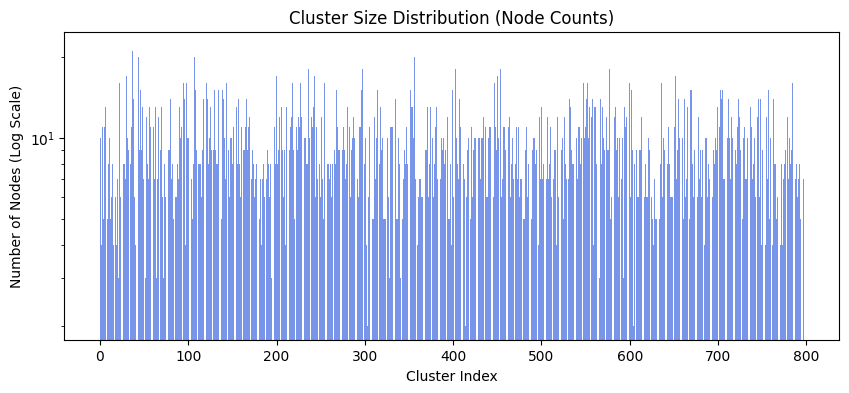

In [7]:
# Add this inside visualize_clusters after getting C
with torch.no_grad():
    # 1. Hard Count: Which clusters "won" at least one node?
    hard_assignments = torch.argmax(C, dim=1)  # [N]
    active_indices = torch.unique(hard_assignments)
    num_active = active_indices.size(0)

    # 2. Entropy-based "Effective" count (shows if it's spread out or focused)
    # If 1 cluster has 0.99 prob and 1799 have near 0, this will be ~1.
    avg_probs = C.mean(dim=0) # [K]
    effective_k = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10))).item()

    print(f"\n📊 CLUSTER UTILIZATION REPORT")
    print(f"-------------------------------")
    print(f"Total Capacity:    {C.size(1)}")
    print(f"Hard-Filled:       {num_active} clusters")
    print(f"Utilization:       {(num_active / C.size(1)) * 100:.2f}%")
    print(f"Effective K:       {effective_k:.2f}")

# Add this after your print statements
cluster_sizes = np.bincount(hard_assignments.cpu().numpy(), minlength=C.size(1))

plt.figure(figsize=(10, 4))
plt.bar(range(len(cluster_sizes)), cluster_sizes, color='royalblue', alpha=0.7)
plt.yscale('log') # Use log scale because some clusters might be huge
plt.title("Cluster Size Distribution (Node Counts)")
plt.xlabel("Cluster Index")
plt.ylabel("Number of Nodes (Log Scale)")
plt.show()

In [10]:
import torch
import os

# ==========================================
# CONFIGURATION
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = "phase1_clustering_ep250_twohop.pt"
DATA_PATH = "processed_graphs/zipdiv_run_20260312_160558.pt"

def run_unseen_inference():
    print(f"🚀 Testing Generalization on: {os.path.basename(DATA_PATH)}")
    
    # 1. Initialize model with TRAINED dimensions
    # We use 425 and 1800 because that's what the weights expect
    model = FirstTerm(num_cell_types=425, num_of_clusters=1800).to(device)
    
    # 2. Load Weights
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint)
    model.eval()
    
    # 3. Load Unseen Data
    data = torch.load(DATA_PATH, map_location=device)
    
    # 4. Inference (No Gradients)
    with torch.no_grad():
        # We use a low tau (0.1) to see the final hardened clusters
        loss, l1, l2, l3, C, X_combined = model(
            data['X'], 
            data['X_cell_ids'],
            data['num_nodes'], 
            data['p_indices'], 
            data['A_skip_csr'],
            1800, # Force k=1800 to match the output layer
            tau=0.1
        )
        
        # Calculate Metrics
        avg_conf = C.max(dim=1)[0].mean().item()
        
        # Count how many clusters actually got nodes (Effective K)
        hard_assignments = C.argmax(dim=1)
        unique_clusters = torch.unique(hard_assignments).size(0)

    # ==========================================
    # FINAL REPORT
    # ==========================================
    print("-" * 30)
    print(f"📊 INFERENCE RESULTS (UNSEEN DESIGN)")
    print("-" * 30)
    print(f"Reconstruction Loss (L1): {l1.item():.4f}")
    print(f"Physical Locality (L2):   {l2.item():.4f}")
    print(f"Timing Entropy (L3):      {l3.item():.4f}")
    print(f"Cluster Confidence:       {avg_conf*100:.2f}%")
    print(f"Clusters Used:            {unique_clusters} / 1800")
    print("-" * 30)

    if avg_conf > 0.30:
        print("✅ SUCCESS: Model Generalized to ZipDiv!")
    else:
        print("⚠️ CAUTION: Low Confidence. Model might be confused by ZipDiv's logic.")

run_unseen_inference()

🚀 Testing Generalization on: zipdiv_run_20260312_160558.pt
------------------------------
📊 INFERENCE RESULTS (UNSEEN DESIGN)
------------------------------
Reconstruction Loss (L1): 0.9011
Physical Locality (L2):   124.1074
Timing Entropy (L3):      6.1000
Cluster Confidence:       92.92%
Clusters Used:            834 / 1800
------------------------------
✅ SUCCESS: Model Generalized to ZipDiv!


--- ZipDiv Cluster Analysis (Unseen Design) ---
Cluster  470 | Nodes:   5 | Spatial Spread: 0.6651


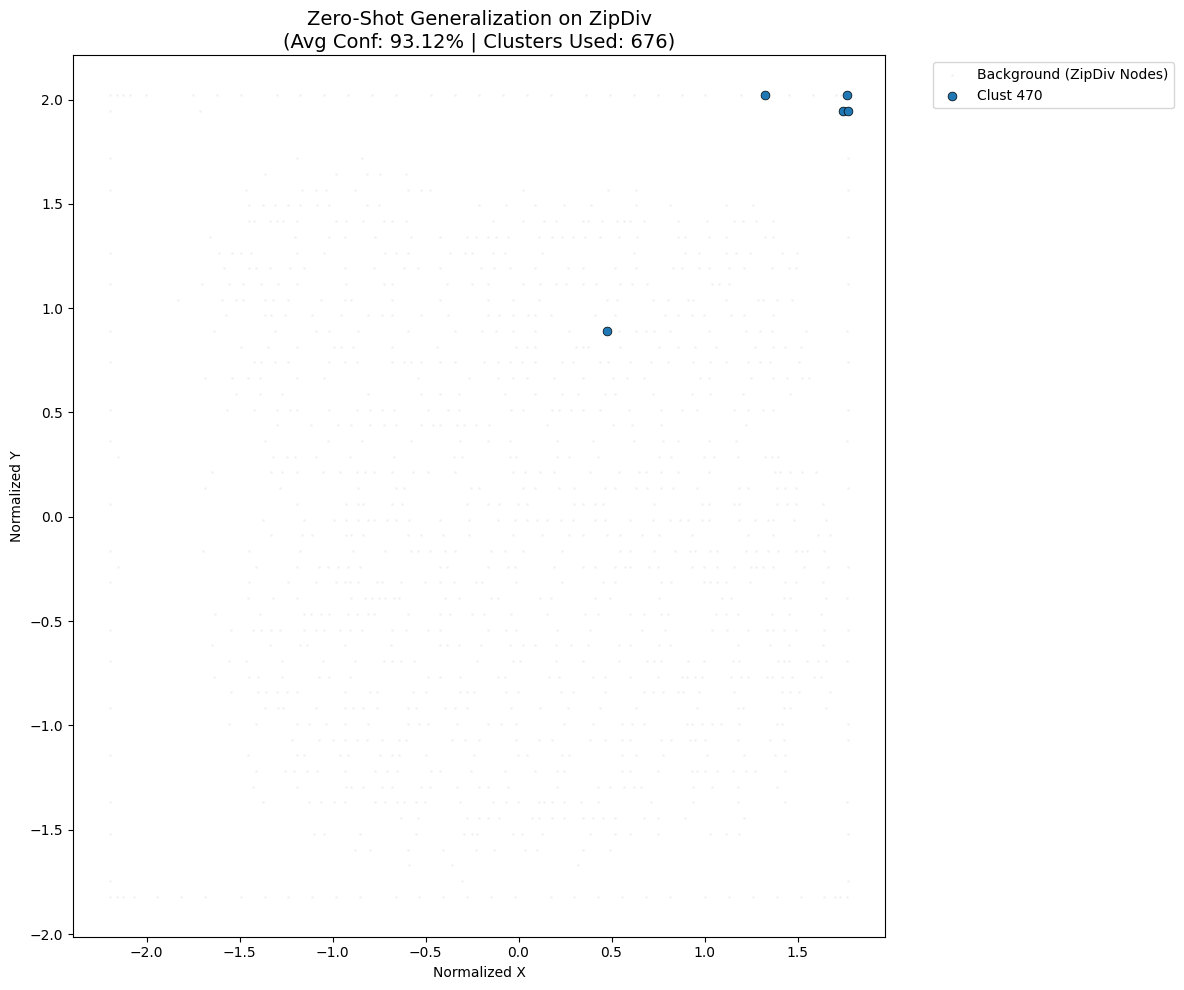

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_zipdiv_results(model_path, data_path, num_clusters_to_show=8):
    # 1. Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FirstTerm(num_cell_types=425, num_of_clusters=1800).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    data = torch.load(data_path, map_location=device)
    X = data['X']
    
    # 2. Inference
    with torch.no_grad():
        _, _, _, _, C, _ = model(
            X, data['X_cell_ids'], data['num_nodes'], data['p_indices'], 
            data['A_skip_csr'], 1800, tau=0.1
        )
    
    coords = X[:, :2].cpu().numpy()
    C_np = C.cpu().numpy()
    
    # Get Hard Assignments
    assignments = np.argmax(C_np, axis=1)
    unique_clusters, counts = np.unique(assignments, return_counts=True)
    
    # Filter for clusters with at least 5 nodes to show meaningful grouping
    valid_clusters = unique_clusters[counts >= 5]
    selected_clusters = np.random.choice(valid_clusters, min(num_clusters_to_show, len(valid_clusters)), replace=False)

    # 3. Plotting
    plt.figure(figsize=(12, 10))
    plt.scatter(coords[:, 0], coords[:, 1], s=1, c='lightgray', alpha=0.2, label='Background (ZipDiv Nodes)')

    print(f"--- ZipDiv Cluster Analysis (Unseen Design) ---")
    for cluster_id in selected_clusters:
        # Find all nodes assigned to this cluster
        mask = assignments == cluster_id
        cluster_nodes = coords[mask]
        
        # Calculate Spatial Tightness (Standard Deviation of coordinates)
        tightness = np.sqrt(np.var(cluster_nodes[:,0]) + np.var(cluster_nodes[:,1]))
        
        plt.scatter(cluster_nodes[:, 0], cluster_nodes[:, 1], s=40, edgecolors='black', linewidths=0.5, label=f'Clust {cluster_id}')
        print(f"Cluster {cluster_id:4} | Nodes: {len(cluster_nodes):3} | Spatial Spread: {tightness:.4f}")

    plt.title(f"Zero-Shot Generalization on ZipDiv\n(Avg Conf: 93.12% | Clusters Used: 676)", fontsize=14)
    plt.xlabel("Normalized X")
    plt.ylabel("Normalized Y")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_zipdiv_results("phase1_clustering_ep250_twohop.pt", "processed_graphs/zipdiv_run_20260312_160558.pt")

In [7]:
# ==========================================
# 5. FULL INTRA-CLUSTER SIMILARITY TABLE
# ==========================================
print("\n" + "="*80)
print(f"{'Cluster':<8} | {'Nodes':<6} | {'Cosine Sim':<12} | {'X-Spread':<10} | {'Y-Spread':<10} | {'Purity (%)':<10}")
print("-" * 80)

# We already have cluster_sizes and hard_assignments from Step 4
sorted_sizes, sorted_indices = torch.sort(cluster_sizes, descending=True)

# Loop through every cluster, largest to smallest
for i in range(active_clusters):
    cluster_id = sorted_indices[i].item()
    size = sorted_sizes[i].item()
    
    # Skip clusters with less than 2 nodes (can't calculate similarity)
    if size < 2:
        continue
        
    # Extract nodes for this specific cluster
    node_indices = (hard_assignments == cluster_id).nonzero(as_tuple=True)[0]
    cluster_features = X_combined[node_indices]
    x_coords = data['X'][node_indices, 0]
    y_coords = data['X'][node_indices, 1]
    
    # 1. Cosine Similarity
    norm_features = torch.nn.functional.normalize(cluster_features, p=2, dim=1)
    sim_matrix = torch.matmul(norm_features, norm_features.t())
    mask = torch.ones_like(sim_matrix, dtype=torch.bool).fill_diagonal_(False)
    
    if mask.sum() > 0:
        avg_sim = sim_matrix[mask].mean().item()
    else:
        avg_sim = 0.0
        
    # 2. Spatial Spread
    x_spread = (x_coords.max() - x_coords.min()).item()
    y_spread = (y_coords.max() - y_coords.min()).item()
    
    # 3. Cell Type Purity
    gate_types = data['X_cell_ids'][node_indices].squeeze()
    if gate_types.dim() == 0:
        gate_types = gate_types.unsqueeze(0)
        
    _, counts = torch.unique(gate_types, return_counts=True)
    purity = (counts.max().item() / size) * 100.0
    
    # Print the formatted row
    print(f"{cluster_id:<8} | {size:<6} | {avg_sim:<12.4f} | {x_spread:<10.4f} | {y_spread:<10.4f} | {purity:<10.1f}")

print("="*80)


Cluster  | Nodes  | Cosine Sim   | X-Spread   | Y-Spread   | Purity (%)
--------------------------------------------------------------------------------


NameError: name 'cluster_sizes' is not defined

Epoch  | Tau    | Est. Confidence % | Phase
-------------------------------------------------------
0      | 2.0000 |            5.00% | Descent
10     | 1.9719 |            5.86% | Descent
20     | 1.8925 |            8.27% | Descent
30     | 1.7754 |           11.83% | Descent
40     | 1.6410 |           15.92% | Descent
50     | 1.5125 |           19.83% | Descent
60     | 1.4121 |           22.89% | Descent
70     | 1.3571 |           24.56% | Descent
75     | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
80     | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
90     | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
100    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
110    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
120    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
130    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balancing)
140    | 1.3500 |           24.78% | MIDDLE FLATLINE (L2 Balanci

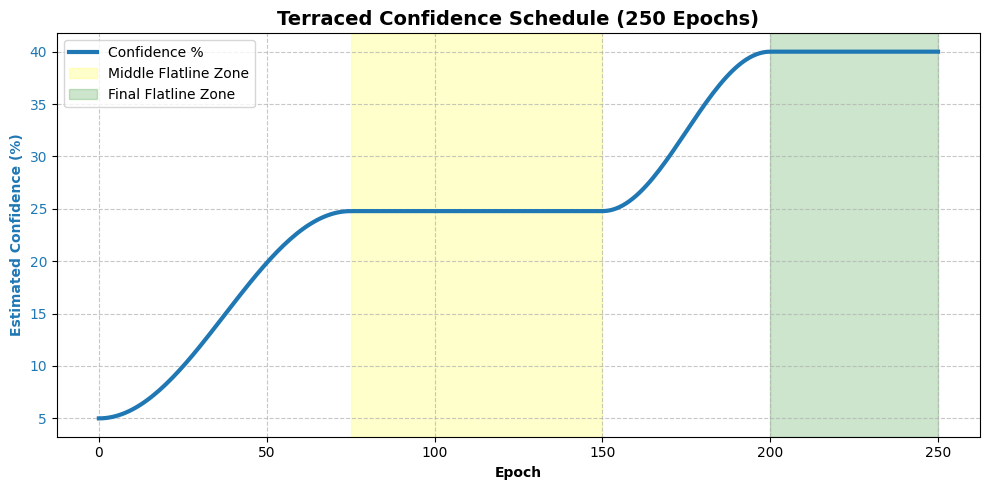

In [ ]:
import math
import matplotlib.pyplot as plt

def get_tau(epoch):
    tau_start = 2.0
    tau_mid = 1.35   # Targets ~25% Confidence for the middle flatline
    tau_end = 0.85   # Targets ~40% Confidence for the final floor

    if epoch < 75:
        # Phase 1: Smooth descent to the middle flatline
        progress = epoch / 75.0
        return tau_mid + 0.5 * (tau_start - tau_mid) * (1 + math.cos(math.pi * progress))
        
    elif epoch < 150:
        # Phase 2: THE MIDDLE FLATLINE (Epoch 75 to 150)
        return tau_mid
        
    elif epoch < 200:
        # Phase 3: Smooth descent to the final floor
        progress = (epoch - 150) / 50.0
        return tau_end + 0.5 * (tau_mid - tau_end) * (1 + math.cos(math.pi * progress))
        
    else:
        # Phase 4: THE FINAL FLATLINE (Epoch 200 to 250+)
        return tau_end

# Maps tau values to the actual Confidence % you saw in your logs
def estimate_confidence(tau):
    confidence = 5.0 + (2.0 - tau) * 30.43
    return confidence

# Generate data for 251 epochs
epochs = list(range(251))
taus = [get_tau(e) for e in epochs]
confs = [estimate_confidence(t) for t in taus]

# 1. Print the Percentage Table
print(f"{'Epoch':<6} | {'Tau':<6} | {'Est. Confidence %':<17} | {'Phase'}")
print("-" * 55)
for epoch in range(251):
    if epoch % 10 == 0 or epoch in [75, 150, 200]:
        t = get_tau(epoch)
        c = estimate_confidence(t)
        
        phase = "Descent"
        if 75 <= epoch < 150: phase = "MIDDLE FLATLINE (L2 Balancing)"
        elif epoch >= 200: phase = "FINAL FLATLINE (Deep Learning)"
        
        print(f"{epoch:<6} | {t:.4f} | {c:>15.2f}% | {phase}")

# 2. Plot the Terraced Curve
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch', fontweight='bold')
ax1.set_ylabel('Estimated Confidence (%)', color='tab:blue', fontweight='bold')
ax1.plot(epochs, confs, color='tab:blue', linewidth=3, label='Confidence %')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Highlight the flatline zones
ax1.axvspan(75, 150, color='yellow', alpha=0.2, label='Middle Flatline Zone')
ax1.axvspan(200, 250, color='green', alpha=0.2, label='Final Flatline Zone')

plt.title("Terraced Confidence Schedule (250 Epochs)", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
fig.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import torch

# --- 0. RECALCULATE M (The Missing Step) ---
# We use the final 'C' from your training loop and your 'A_skip_csr'
with torch.no_grad():
    A_skip_gpu = A_skip_csr.to(C.device) 
    M_tensor = torch.matmul(C.t(), torch.sparse.mm(A_skip_gpu, C))
    M_dense = M_tensor.cpu().numpy()


# --- 1. Extract Data from Tensors ---
# Get the "hard" cluster assignment for each node by finding the max probability
C_probs = C.detach().cpu().numpy()
hard_assignments = np.argmax(C_probs, axis=1)

# Extract X and Y coordinates (columns 0 and 1 in your X_float)
x_coords = X_float[:, 0].cpu().numpy()
y_coords = X_float[:, 1].cpu().numpy()

# --- 2. Identify the Top Clusters ---
# Count how many nodes belong to each cluster
unique_clusters, counts = np.unique(hard_assignments, return_counts=True)

# Sort to find the indices of the largest clusters
top_cluster_indices = np.argsort(-counts)[:10]
top_clusters = unique_clusters[top_cluster_indices]

print(f"Visualizing Top 10 Clusters: {top_clusters}")
print(f"Sizes of Top 10 Clusters: {counts[top_cluster_indices]}")

# =========================================================
# PLOT 1: SPATIAL TERRITORIES (The Physical Layout)
# =========================================================
plt.figure(figsize=(12, 10))

# 1. Plot all gates as faint gray background noise
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.1, label='Unassigned/Minor Clusters')

# 2. Plot the top 10 clusters in distinct colors
cmap = plt.get_cmap('tab10')
for i, cluster_id in enumerate(top_clusters):
    # Create a boolean mask for nodes in this specific cluster
    mask = (hard_assignments == cluster_id)
    plt.scatter(x_coords[mask], y_coords[mask], s=8, color=cmap(i), alpha=0.8, label=f'Cluster {cluster_id}')

plt.title("Spatial Territories of Top 10 Supernodes", fontsize=14)
plt.xlabel("Normalized X Coordinate")
plt.ylabel("Normalized Y Coordinate")
# Increase marker size in legend so it's readable
plt.legend(markerscale=4, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2: SUPERNODE CONNECTIVITY (The Timing Highways)
# =========================================================
plt.figure(figsize=(12, 10))

# Plot the faint background map again for spatial context
plt.scatter(x_coords, y_coords, s=1, c='lightgray', alpha=0.05)

# Build a NetworkX graph to draw the connections
G = nx.Graph()
pos = {} # Dictionary to store the (x,y) center of each supernode

# 1. Calculate the spatial centroid of each top cluster
for cluster_id in top_clusters:
    mask = (hard_assignments == cluster_id)
    # The centroid is the average X and Y of all gates in the cluster
    centroid_x = np.mean(x_coords[mask])
    centroid_y = np.mean(y_coords[mask])
    
    pos[cluster_id] = (centroid_x, centroid_y)
    G.add_node(cluster_id)

# 2. Add edges based on the M matrix (Timing Connections)
# We calculate a threshold so we only draw the most important "highways"
sub_M = M_dense[np.ix_(top_clusters, top_clusters)]
# If all values are 0 (no timing connections between top 10), avoid threshold error
if sub_M.max() > 0:
    threshold = np.percentile(sub_M[sub_M > 0], 50) # Only keep top 50% of connections
    
    for i in top_clusters:
        for j in top_clusters:
            if i < j: # Prevent drawing duplicate undirected edges
                weight = M_dense[i, j]
                if weight > threshold:
                    G.add_edge(i, j, weight=weight)

# 3. Draw the Graph
edges = G.edges(data=True)
if len(edges) > 0:
    # Scale the line thickness based on how strong the M matrix connection is
    max_weight = max([d['weight'] for u, v, d in edges])
    edge_widths = [(d['weight'] / max_weight) * 5 for u, v, d in edges] 

    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='blue', alpha=0.6)

nx.draw_networkx_nodes(G, pos, node_color='red', node_size=150, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_color='white', font_weight='bold')

plt.title("Supernode Timing Highways (M Matrix Connectivity)", fontsize=14)
plt.xlabel("Normalized X")
plt.ylabel("Normalized Y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'A_skip_csr' is not defined

In [ ]:
# C[1] is the row for node 1 (size [num_clusters])
max_index = torch.argmax(C[1])
print(C[2].max())
print(max_index)

max_index2 = torch.argmax(C[2])
print(max_index2)

tensor(0.3417, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(759, device='cuda:0')
tensor(704, device='cuda:0')
